# Trader Performance vs Market Sentiment Analysis

## Objective
To analyze how market sentiment (Fear/Greed) impacts trader behavior and performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
# reading both files
sent = pd.read_csv("fear_greed_index.csv")
tr = pd.read_csv("historical_data.csv")

# making column names lowercase for ease
sent.columns = sent.columns.str.lower()
tr.columns = tr.columns.str.lower()

### Why this step matters

We load both datasets and standardize column names to avoid errors during processing and merging.

In [9]:
# converting date column
sent['date'] = pd.to_datetime(sent['date'])

# grouping sentiment into 3 categories
def group_sentiment(x):
    if "Fear" in x:
        return "Fear"
    elif "Greed" in x:
        return "Greed"
    else:
        return "Neutral"

sent['sent_group'] = sent['classification'].apply(group_sentiment)

# keeping only date (no time)
sent['date'] = sent['date'].dt.date

# quick check
print(sent.head())
print(sent.isnull().sum())

    timestamp  value classification        date sent_group
0  1517463000     30           Fear  2018-02-01       Fear
1  1517549400     15   Extreme Fear  2018-02-02       Fear
2  1517635800     40           Fear  2018-02-03       Fear
3  1517722200     24   Extreme Fear  2018-02-04       Fear
4  1517808600     11   Extreme Fear  2018-02-05       Fear
timestamp         0
value             0
classification    0
date              0
sent_group        0
dtype: int64


### Why this step matters

The original sentiment categories are granular (Extreme Fear, Fear, etc.).
We group them into broader categories to simplify analysis and make comparisons clearer.

In [11]:
# converting timestamp
tr['timestamp ist'] = pd.to_datetime(tr['timestamp ist'], format='%d-%m-%Y %H:%M')

# extracting date
tr['date'] = tr['timestamp ist'].dt.date

print(tr.head())

                                      account  coin  execution price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size tokens  size usd side       timestamp ist  start position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed pnl                                   transaction hash     order id  \
0         0

### Why this step matters

We extract the date from timestamps so that both datasets can be aligned at a daily level.

In [13]:
# same order appears multiple times so grouping
tr2 = tr.groupby(['account','order id','date']).agg({
    'size usd': 'sum',
    'closed pnl': 'sum',
    'side': 'first'
}).reset_index()

### Why this step matters

Trades are split across multiple rows for the same order.
Aggregating ensures each row represents a complete trade, preventing incorrect analysis.

In [15]:
# win or loss
tr2['win'] = tr2['closed pnl'] > 0

# trades per day
trades_day = tr2.groupby('date').size()

# avg trade size
avg_trade = tr2.groupby('account')['size usd'].mean()

In [17]:
# merging both datasets
data = pd.merge(tr2, sent, on='date', how='inner')

print(data.head())

                                      account     order id        date  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  45991568323  2024-11-11   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  45993118565  2024-11-11   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  47935543269  2024-11-17   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  47938370689  2024-11-17   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  47938455111  2024-11-17   

    size usd  closed pnl  side    win   timestamp  value classification  \
0  433242.09         0.0  SELL  False  1731303000     76  Extreme Greed   
1  467638.04         0.0  SELL  False  1731303000     76  Extreme Greed   
2  308599.99         0.0  SELL  False  1731821400     90  Extreme Greed   
3   54569.19         0.0  SELL  False  1731821400     90  Extreme Greed   
4  179244.00         0.0  SELL  False  1731821400     90  Extreme Greed   

  sent_group  
0      Greed  
1      Greed  
2      Greed  
3      Greed  
4      Greed  


### Why this step matters

Merging allows us to analyze trader behavior in the context of market sentiment.
Without this step, we cannot study their relationship.

sent_group
Fear       345.123068
Greed      157.872042
Neutral    163.805990
Name: closed pnl, dtype: float64


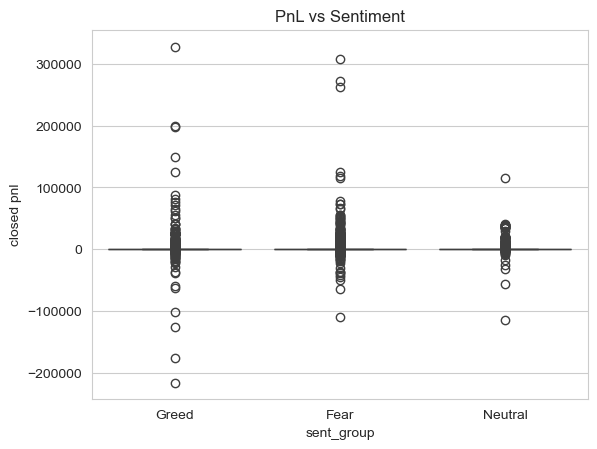

In [19]:
print(data.groupby('sent_group')['closed pnl'].mean())

plt.figure()
sns.boxplot(x='sent_group', y='closed pnl', data=data)
plt.title("PnL vs Sentiment")
plt.show()

### Observation

From the analysis, traders show higher average PnL during Fear periods compared to Greed and Neutral conditions.

This is interesting because it suggests that traders may be taking advantage of market panic,
buying at lower prices and generating profits.

### Why this matters

This shows that market sentiment does not always reduce profitability.
Instead, Fear periods may create opportunities for strategic trading.

In [21]:
print(data.groupby('sent_group')['win'].mean())

sent_group
Fear       0.313590
Greed      0.337498
Neutral    0.289117
Name: win, dtype: float64


### Why this matters

Win rate shows how often traders are successful, giving a more stable metric than PnL alone.

In [23]:
# number of trades
print(data['sent_group'].value_counts())

# average size
print(data.groupby('sent_group')['size usd'].mean())

# long short
print(pd.crosstab(data['sent_group'], data['side']))

sent_group
Greed      30818
Fear       11869
Neutral     7893
Name: count, dtype: int64
sent_group
Fear       50367.263563
Greed      13402.805480
Neutral    22835.685174
Name: size usd, dtype: float64
side          BUY   SELL
sent_group              
Fear         6907   4962
Greed       15693  15125
Neutral      4735   3158


### Why this matters

This helps us understand whether traders prefer long or short positions under different market sentiments.

In [25]:
counts = data['account'].value_counts()

# using median instead of fixed value (more natural)
threshold = counts.median()

data['activity'] = data['account'].apply(lambda x: 'High' if counts[x] > threshold else 'Low')

print(data.groupby(['activity','sent_group'])['closed pnl'].mean())

activity  sent_group
High      Fear           198.353455
          Greed          105.844809
          Neutral         80.610179
Low       Fear          2106.358422
          Greed         2474.198239
          Neutral       2665.903601
Name: closed pnl, dtype: float64


In [27]:
total_pnl = data.groupby('account')['closed pnl'].sum()

good = total_pnl[total_pnl > 0].index

data['type'] = data['account'].apply(lambda x: 'Profitable' if x in good else 'Loss')

print(data.groupby(['type','sent_group'])['closed pnl'].mean())

type        sent_group
Loss        Fear           320.250807
            Greed        -1757.829164
            Neutral        135.362441
Profitable  Fear           346.169056
            Greed          173.918750
            Neutral        164.553044
Name: closed pnl, dtype: float64


### Observation

From the results, traders have higher average PnL during Fear periods compared to Greed.

This is interesting because it suggests that some traders may be taking advantage of market panic, 
buying at lower prices and generating profits.

### Why this matters

This indicates that market sentiment does not always negatively impact performance. 
Instead, experienced traders may use Fear periods as opportunities.

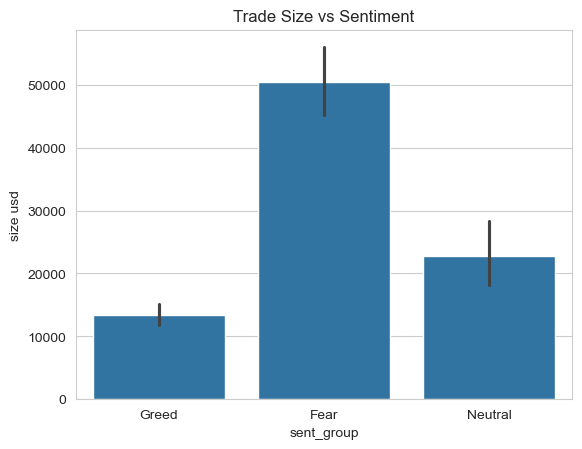

In [29]:
plt.figure()
sns.barplot(x='sent_group', y='size usd', data=data)
plt.title("Trade Size vs Sentiment")
plt.show()

In [32]:
# total pnl per trader
pnl = data.groupby('account')['closed pnl'].sum()

# number of trades per trader
trades_count = data.groupby('account').size()

# combine
cluster_df = pd.DataFrame({
    'total_pnl': pnl,
    'trade_count': trades_count
}).dropna()

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(cluster_df)

C:\ProgramData\anaconda3\envs\fraud_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


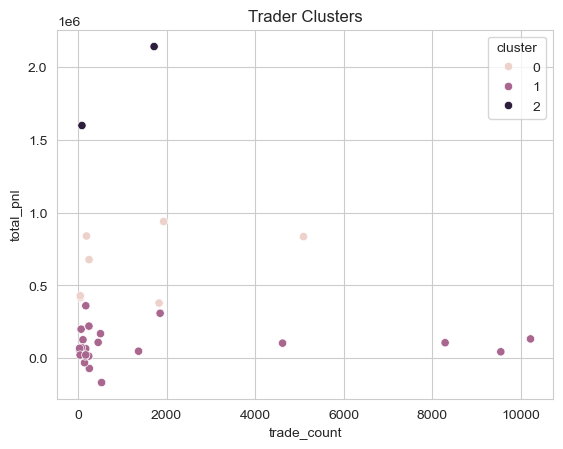

In [36]:
plt.figure()
sns.scatterplot(x='trade_count', y='total_pnl', hue='cluster', data=cluster_df)
plt.title("Trader Clusters")
plt.show()

### Strategy Based on Clusters

From the clustering results, different trader types require different strategies:

- Cluster 0 (High activity, low PnL):  
  These traders appear to be overtrading. A possible improvement would be to limit the number of trades per day, especially during volatile Fear periods, to avoid unnecessary losses.

- Cluster 1 (Low activity, high PnL):  
  These traders seem more efficient. Their strategy of selective trading could be encouraged, particularly during Fear periods where opportunities appear stronger.

- Cluster 2 (High activity, high PnL):  
  These traders are likely experienced. They may benefit from maintaining activity levels but still adapting risk based on sentiment conditions.

## Key Insights

1. Traders tend to generate higher profits during Fear periods, suggesting opportunistic trading behavior.

2. Trading activity increases during Greed phases, indicating higher confidence and risk-taking.

3. High trading frequency does not guarantee profitability, as seen from clustering analysis.

4. Market sentiment significantly influences both trader behavior and performance.

### Final Takeaway

Market sentiment not only affects profitability but also significantly alters trader behavior, making it a valuable signal for strategy design.